In [5]:
import os
import ast
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:
csv_path = "/kaggle/input/nh-chest-xrays-reduced-dataset/reduced_data.csv"
img_dir = "/kaggle/input/nh-chest-xrays-reduced-dataset/images/images"

df = pd.read_csv(csv_path)

df["Finding Labels"] = df["Finding Labels"].apply(ast.literal_eval)

all_labels = sorted(list({lab for sub in df["Finding Labels"] for lab in sub}))
mlb = MultiLabelBinarizer(classes=all_labels)
df["targets"] = mlb.fit_transform(df["Finding Labels"]).tolist()

num_classes = len(all_labels)
num_classes, all_labels

(15,
 ['Atelectasis',
  'Cardiomegaly',
  'Consolidation',
  'Edema',
  'Effusion',
  'Emphysema',
  'Fibrosis',
  'Hernia',
  'Infiltration',
  'Mass',
  'No Finding',
  'Nodule',
  'Pleural_Thickening',
  'Pneumonia',
  'Pneumothorax'])

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
class NIHChestDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.images = df["Image Index"].values
        self.targets = df["targets"].values
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        target = torch.tensor(self.targets[idx]).float()
        return img, target

In [9]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [10]:
train_df, val_df = train_test_split(df, test_size=0.15, random_state=42)

train_dataset = NIHChestDataset(train_df, img_dir, transform=train_transforms)
val_dataset   = NIHChestDataset(val_df,   img_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

In [ ]:
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)

#model.load_state_dict(torch.load('/kaggle/input/nih-chest-xray-reduced-resnet50/pytorch/default/1/best_resnet50_nih.pth', map_location=device, weights_only=True))
model.to(device)
model.eval()

In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3)

In [16]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [17]:
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            

            total_labels = 0 

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    
        
                    preds = torch.sigmoid(outputs) > 0.5
                    
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                
                
                running_corrects += torch.sum(preds == labels.data.bool())
                total_labels += inputs.size(0) * labels.size(1)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / total_labels

            print(f"{phase} Loss: {epoch_loss:.4f} Acc (Global por label): {epoch_acc:.4f}")

            if phase == 'val':
                scheduler.step(epoch_loss)

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    save_path = "best_resnet50.pth"
                    torch.save(model.state_dict(), save_path)

    print(f"\nTreinamento concluído! Melhor acurácia de validação: {best_acc:.4f}")

In [14]:
train_model(model, criterion, optimizer, scheduler, num_epochs=5)


Época 1/5
------------------------------
train Loss: 0.3818 Acc (Global por label): 0.8594
val Loss: 0.3432 Acc (Global por label): 0.8704

Época 2/5
------------------------------
train Loss: 0.3314 Acc (Global por label): 0.8700
val Loss: 0.3344 Acc (Global por label): 0.8689

Época 3/5
------------------------------
train Loss: 0.3110 Acc (Global por label): 0.8748
val Loss: 0.3139 Acc (Global por label): 0.8757

Época 4/5
------------------------------
train Loss: 0.2929 Acc (Global por label): 0.8806
val Loss: 0.3103 Acc (Global por label): 0.8777

Época 5/5
------------------------------
train Loss: 0.2767 Acc (Global por label): 0.8863
val Loss: 0.3084 Acc (Global por label): 0.8774

Treinamento concluído! Melhor acurácia de validação: 0.8777


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from scipy.stats import pearsonr
from skimage.measure import label
def get_heatmap(model, model_name, explain_fn, img_tensor, target=None):
    if model_name == 'GradCAM' or model_name == 'RISE':
        base_heatmap = explain_fn(img_tensor)
    elif model_name == 'ScoreCAM':
        base_heatmap = explain_fn(img_tensor, target) 
    elif model_name == 'IG':
        output = model(img_tensor)
        pred_prob = F.softmax(output, dim=1)
        pred_class_idx = torch.argmax(pred_prob, dim=1).item()
        baseline = torch.zeros_like(img_tensor).to(img_tensor.device)
        base_heatmap = explain_fn(img_tensor,
                                   baselines=baseline,
                                   target=pred_class_idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    
    return base_heatmap

## FIDELITY
def deletion_test(model, img_tensor, heatmap, correct_class, max_steps=20, pixels_per_step = 5, deletion_value=0.0):
    model.eval()

    img = img_tensor.clone()
    C, H, W = img.shape[1], img.shape[2], img.shape[3]

    heat = heatmap.astype(np.float32)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8) # Norm

    flat = heat.flatten()
    num_pixels = len(flat)

    sorted_idx = np.argsort(-flat)  # Descending order

    confidences = []
    predictions = []

    broke = None
    for step in range(1, max_steps + 1):
        start = (step-1) * pixels_per_step
        end = min(step * pixels_per_step, num_pixels)
        idx_to_delete = sorted_idx[start:end]

        if len(idx_to_delete) == 0:
            break

        for idx in idx_to_delete:
            h = idx // W
            w = idx % W
            img[0, :, h, w] = deletion_value



        with torch.no_grad():
            logits = model(img)
            probs = torch.sigmoid(logits)[0]
            # labels com prob > 0.5
            predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
            if correct_class not in predicted and broke is None:
                broke = step
                return confidences, predictions, broke

    return confidences, predictions, broke

## ROBUSTNESS
def robustness_test(model, model_name, img_tensor, explain_fn, target=None, sigma=0.1, n_perturb=5):
    model.eval()

    base_heatmap = get_heatmap(model, model_name, explain_fn, img_tensor, target)
    
    base_flat = base_heatmap.flatten()

    correlations = []

    for _ in range(n_perturb):

        # Adiciona ruído gaussiano à imagem
        noise = torch.randn_like(img_tensor) * sigma
        noisy_img = img_tensor + noise

        noisy_heatmap = get_heatmap(model, model_name, explain_fn, noisy_img, target)

        noisy_flat = noisy_heatmap.flatten()


        if isinstance(base_flat, torch.Tensor):
            base_flat = base_flat.detach().cpu().numpy()
        else:
            base_flat = np.array(base_flat)

        if isinstance(noisy_flat, torch.Tensor):
            noisy_flat = noisy_flat.detach().cpu().numpy()
        else:
            noisy_flat = np.array(noisy_flat)
        r, _ = pearsonr(base_flat, noisy_flat)

        correlations.append(r)

    # Média das correlações
    return np.mean(correlations)



## SPARSITY AND SPATIAL COHERENCE
def calculate_gini_index(heatmap):
    h_flat = np.abs(heatmap.flatten())
    h_sorted = np.sort(h_flat)
    n = len(h_sorted)
    if n == 0 or np.sum(h_sorted) == 0: return 0.0
    cum_sum = np.cumsum(h_sorted)
    B = np.sum(cum_sum) / cum_sum[-1]
    gini = (n + 1 - 2 * B) / n
    return gini

def calculate_spatial_coherence(heatmap, threshold_percent=0.5):
    if np.max(heatmap) - np.min(heatmap) < 1e-7: return 1.0
    h_norm = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-7)
    threshold = threshold_percent * np.max(h_norm)
    binary_map = h_norm > threshold
    labeled_map, num_labels = label(binary_map, connectivity=2, background=0, return_num=True)
    if num_labels == 0: return 0.0
    total_energy = np.sum(h_norm[binary_map])
    if total_energy == 0: return 0.0
    max_cluster_energy = 0
    for i in range(1, num_labels + 1):
        cluster_mask = labeled_map == i
        cluster_energy = np.sum(h_norm[cluster_mask])
        if cluster_energy > max_cluster_energy:
            max_cluster_energy = cluster_energy
    return max_cluster_energy / total_energy


## INTRA-CLASS CONSISTENCY

def intraclass_consistency(lista_heatmaps):
    heatmaps_flat = np.array([h.flatten() for h in lista_heatmaps])
    matriz_corr = np.corrcoef(heatmaps_flat)
    indices_tri_sup = np.triu_indices_from(matriz_corr, k=1)
    correlacoes = matriz_corr[indices_tri_sup]
    score_consistencia = np.mean(correlacoes)
    return score_consistencia

In [13]:
image_paths = ['/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00022604_015.png',
              '/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00019176_052.png',
              '/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00030079_022.png',
              '/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00011237_066.png']

In [14]:
img_path = '/kaggle/input/nh-chest-xrays-reduced-dataset/images/images/00011237_066.png'


raw_img = Image.open(img_path).convert("RGB")
input_tensor = val_transforms(raw_img).unsqueeze(0).to(next(model.parameters()).device)


model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    probs = torch.sigmoid(logits)[0]

# labels com prob > 0.5
predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
predicted

['Infiltration']

In [25]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        self.model.zero_grad()
        class_score = output[0, class_idx]
        class_score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1).squeeze()

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()
        cam = cam.cpu().numpy()
        
        cam = cv2.resize(cam, (224, 224))
        return cam

In [26]:
target_layer = model.layer4[-1]

gradcam = GradCAM(model, target_layer)

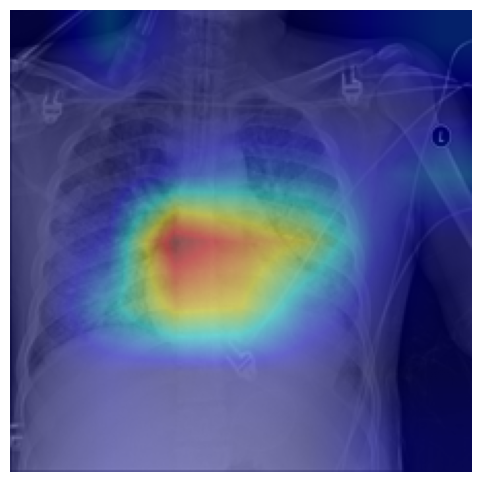

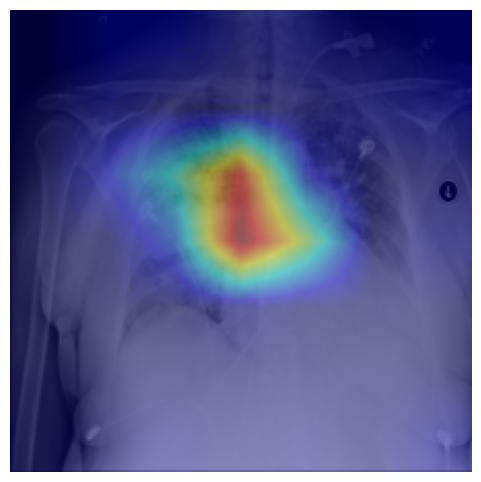

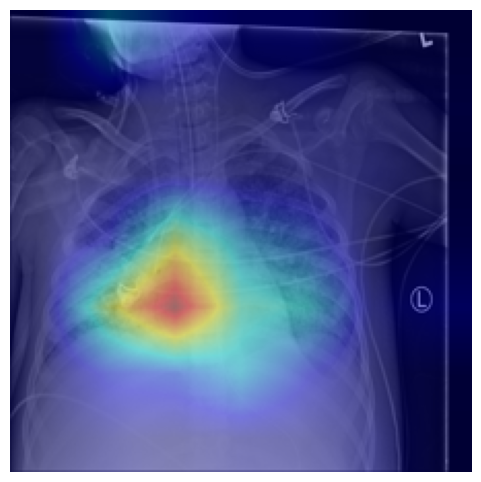

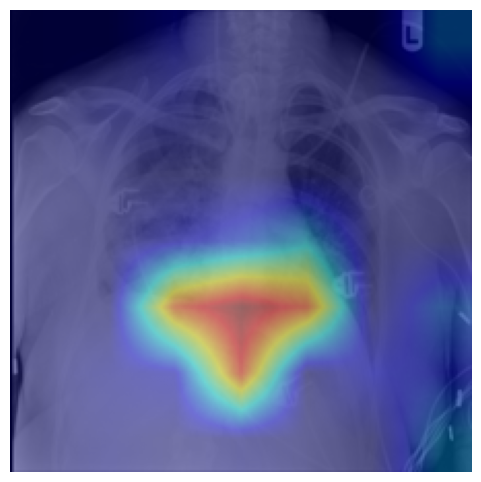

In [29]:
for img_path in image_paths:
    raw_img = Image.open(img_path).convert("RGB")
    input_tensor = val_transforms(raw_img).unsqueeze(0).to(next(model.parameters()).device)
    
    
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    predicted
    
    cam = gradcam.generate(input_tensor)
    heatmap = cv2.applyColorMap(np.uint8(255 * (1 - cam)), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    
    raw_np = np.array(raw_img.resize((224, 224))) / 255.0
    overlay = heatmap * 0.4 + raw_np * 0.6
    overlay = np.clip(overlay, 0, 1)
    
    # Salva e exibe
    #save_path = os.path.join(Config.OUTPUT_DIR, f"gradcam_{img_name}")
    #plt.imsave(save_path, overlay)
    #print(f"Grad-CAM salvo em: {save_path}")
    
    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

In [31]:
broke_list = []
heatmaps = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]

    cam = gradcam.generate(input_tensor)
    if len(cam.shape) == 3:
        cam = cam[0]

    heatmap = cam
    heatmaps.append(heatmap)
    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, 'Infiltration' , max_steps=3000)
    print(f"Broke at step: {broke}")
    broke_list.append(broke)


print("Broke_mean:", np.mean(broke_list))

Broke at step: 194
Broke at step: 1
Broke at step: 1221
Broke at step: 2
Broke_mean: 354.5


In [32]:

robustness_scores = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)


    robustness_score = robustness_test(model, 'GradCAM', input_tensor, gradcam.generate)
    print(f"Robustness score: {robustness_score}")
    robustness_scores.append(robustness_score)

print(f"Average robustness score: {np.mean(robustness_scores)}")

Robustness score: -0.1145859807729721
Robustness score: 0.28557220101356506
Robustness score: -0.1326286494731903
Robustness score: 0.036632172763347626
Average robustness score: 0.018747437745332718


In [33]:

from skimage.measure import label

gini_list = []
coherence_list = []
for heatmap in heatmaps:
    grayscale_cam = heatmap
    gini_index = calculate_gini_index(grayscale_cam)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)

    coherence = calculate_spatial_coherence(grayscale_cam)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print(f"Average Gini Index: {np.mean(gini_list)}")
print(f"Average Spatial Coherence: {np.mean(coherence_list)}")

Gini Index: 0.6421844715974769
Spatial Coherence: 1.0
Gini Index: 0.7353711030921157
Spatial Coherence: 1.0
Gini Index: 0.6363092150006976
Spatial Coherence: 1.0
Gini Index: 0.7411430903843471
Spatial Coherence: 1.0
Average Gini Index: 0.6887519700186594
Average Spatial Coherence: 1.0


In [34]:
consistency = intraclass_consistency(heatmaps)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.47239073448728336


In [35]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.3 MB/s eta 0:00:00:

In [36]:
from skimage.transform import resize
import matplotlib.pyplot as plt
import os
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

100%|██████████| 128/128 [00:07<00:00, 17.29it/s]


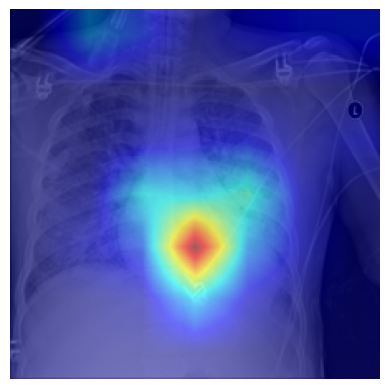

100%|██████████| 128/128 [00:07<00:00, 16.48it/s]


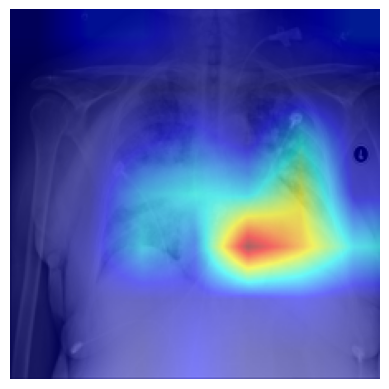

100%|██████████| 128/128 [00:07<00:00, 16.08it/s]


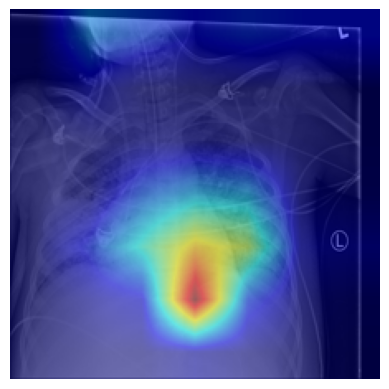

100%|██████████| 128/128 [00:07<00:00, 16.37it/s]


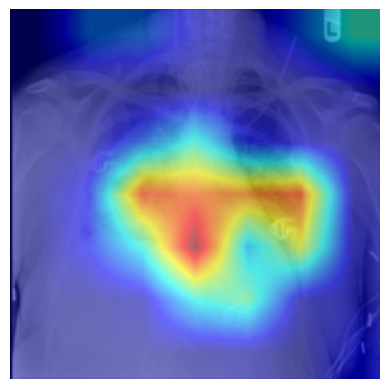

In [37]:
heatmaps_score = []
for img_path in image_paths:
    img = Image.open(img_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)
    
    
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    
    
    idx = all_labels.index("Infiltration")
    targets = [ClassifierOutputTarget(idx)]
    
    target_layer = model.layer4[-1]
    cam = ScoreCAM(model=model, target_layers=[target_layer])
    
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam = grayscale_cam / grayscale_cam.max()
    heatmaps_score.append(grayscale_cam)
    
    rgb_img = np.array(img.resize((224, 224))) / 255.0
    vis = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    plt.imshow(vis)
    plt.axis('off')
    plt.show()

In [39]:
broken_list = []
for image_path, heatmap in zip(image_paths, heatmaps_score):
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    idx = all_labels.index("Infiltration")
    targets = [ClassifierOutputTarget(idx)]
    
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam = grayscale_cam / grayscale_cam.max()

    if len(grayscale_cam.shape) == 3:
        grayscale_cam = grayscale_cam[0]

    confidences, predictions, broken = deletion_test(model, input_tensor, grayscale_cam, 'Infiltration', max_steps=3000)
    if broken is not None:
        broken_list.append(broken)
    
    print(f"Broken at step: {broken}")

print(f"Average broken step: {np.mean(broken_list)}")



100%|██████████| 128/128 [00:06<00:00, 18.91it/s]


Broken at step: 2632


100%|██████████| 128/128 [00:07<00:00, 17.43it/s]


Broken at step: 4


100%|██████████| 128/128 [00:07<00:00, 17.84it/s]


Broken at step: 2185


100%|██████████| 128/128 [00:07<00:00, 17.93it/s]

Broken at step: 3
Average broken step: 1206.0


In [40]:
robustness_scores = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0)
    idx = all_labels.index("Infiltration")
    targets = [ClassifierOutputTarget(idx)]

    robustness_score = robustness_test(model, 'ScoreCAM', input_tensor, cam, targets)
    print(f"Robustness score: {robustness_score}")
    robustness_scores.append(robustness_score)

print(f"Average robustness score: {np.mean(robustness_scores)}")

100%|██████████| 128/128 [00:07<00:00, 16.69it/s]


Robustness score: -0.030583849176764488


100%|██████████| 128/128 [00:06<00:00, 18.85it/s]


Robustness score: 0.013659070245921612


100%|██████████| 128/128 [00:07<00:00, 17.83it/s]


Robustness score: 0.06867344677448273


100%|██████████| 128/128 [00:06<00:00, 18.37it/s]

Robustness score: 0.055333178490400314
Average robustness score: 0.026770461350679398


In [41]:
gini_list = []
coherence_list = []
for heatmap in heatmaps_score:
    grayscale_cam = heatmap
    gini_index = calculate_gini_index(grayscale_cam)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)

    coherence = calculate_spatial_coherence(grayscale_cam)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print(f"Average Gini Index: {np.mean(gini_list)}")
print(f"Average Spatial Coherence: {np.mean(coherence_list)}")

Gini Index: 0.6307531084333148
Spatial Coherence: 1.0
Gini Index: 0.6005063348886918
Spatial Coherence: 1.0
Gini Index: 0.644388315628986
Spatial Coherence: 1.0
Gini Index: 0.5968006289735133
Spatial Coherence: 1.0
Average Gini Index: 0.6181120969811265
Average Spatial Coherence: 1.0


In [42]:
consistency = intraclass_consistency(heatmaps_score)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.682794556353556


In [15]:
class RISE(nn.Module):
    def __init__(self, model, input_size, gpu_batch=10):
        super(RISE, self).__init__()
        self.model = model
        self.input_size = input_size
        self.gpu_batch = gpu_batch
    
    def generate_masks(self, N, s, p1, savepath='masks.npy'):
        from skimage.transform import resize
        
        cell_size = np.ceil(np.array(self.input_size) / s)
        up_size = (s + 1) * cell_size
        grid = np.random.rand(N, s, s) < p1
        grid = grid.astype('float32')
        self.masks = np.empty((N, *self.input_size))
        
        for i in tqdm(range(N), desc='Generating filters'):
            x = np.random.randint(0, cell_size[0])
            y = np.random.randint(0, cell_size[1])
            self.masks[i, :, :] = resize(grid[i], up_size, order=1, mode='reflect',
                                         anti_aliasing=False)[x:x + self.input_size[0], y:y + self.input_size[1]]
        
        self.masks = self.masks.reshape(-1, 1, *self.input_size)
        np.save(savepath, self.masks)
        self.N = N
        self.p1 = p1
    
    def load_masks(self, filepath):
        self.masks = np.load(filepath)
        self.N = self.masks.shape[0]
    
    def forward(self, x):
        N = self.N
        B, C, H, W = x.size()
        
        p_list = []
        
        for i in tqdm(range(0, N, self.gpu_batch), desc='Processing masks'):
            end_idx = min(i + self.gpu_batch, N)
            
            batch_masks = torch.from_numpy(self.masks[i:end_idx]).float().to(x.device)
 
            stack = torch.mul(batch_masks, x.data)

            with torch.no_grad():
                batch_p = self.model(stack)
                p_list.append(batch_p.cpu())  
            
            del batch_masks, stack
            torch.cuda.empty_cache()
        

        p = torch.cat(p_list).to(x.device)

        CL = p.size(1)
        
        sal = torch.zeros((CL, H * W), device=x.device)
        
        for i in range(0, N, self.gpu_batch):
            end_idx = min(i + self.gpu_batch, N)
            batch_masks = torch.from_numpy(self.masks[i:end_idx]).float().to(x.device)
            batch_p = p[i:end_idx]
            
            sal += torch.matmul(batch_p.data.transpose(0, 1), 
                               batch_masks.view(end_idx - i, H * W))
            
            del batch_masks
            torch.cuda.empty_cache()
        
        sal = sal.view((CL, H, W))
        sal = sal / N / self.p1
        
        return sal

In [16]:
input_size = (224, 224)
explainer = RISE(model, input_size, gpu_batch=100)

In [ ]:
N = 3000  
s = 8     
p1 = 0.5 

print("Gerando máscaras...")
explainer.generate_masks(N=N, s=s, p1=p1, savepath='')

Gerando máscaras...


Generating filters: 100%|██████████| 3000/3000 [00:05<00:00, 511.33it/s]


Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [00:09<00:00,  3.32it/s]


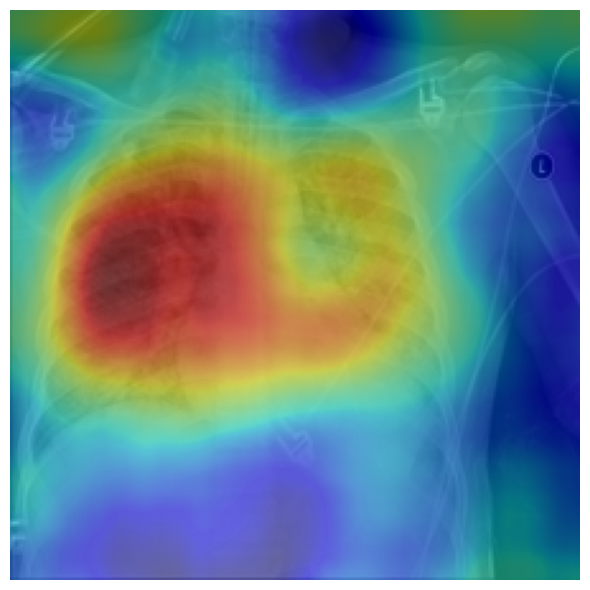

Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [00:08<00:00,  3.34it/s]


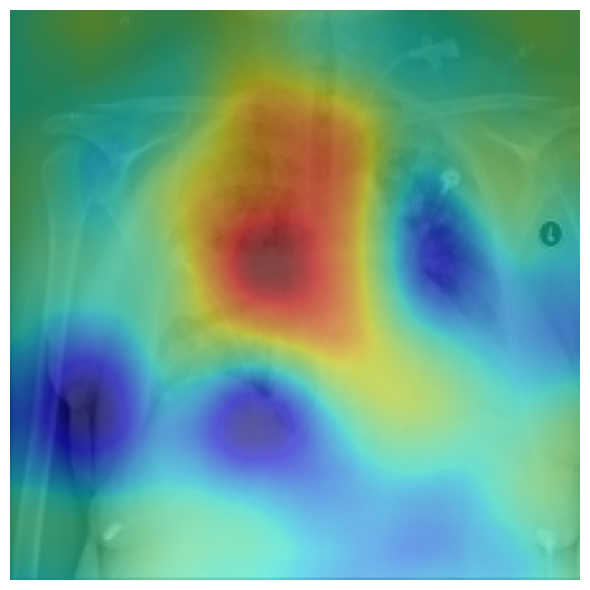

Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [00:09<00:00,  3.29it/s]


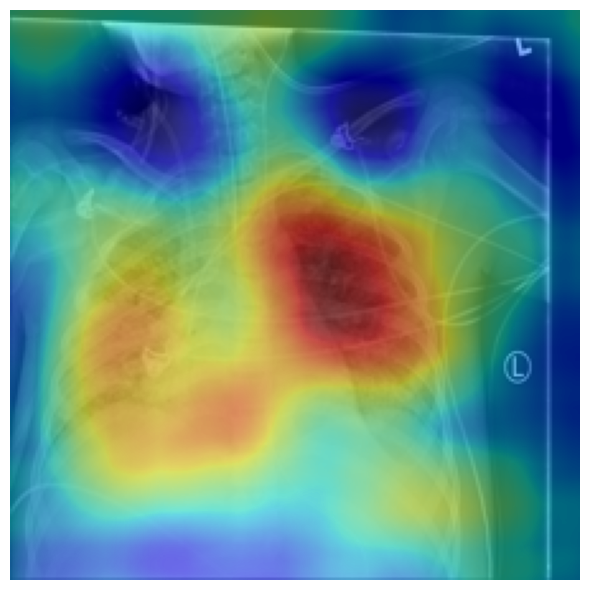

Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [00:09<00:00,  3.25it/s]


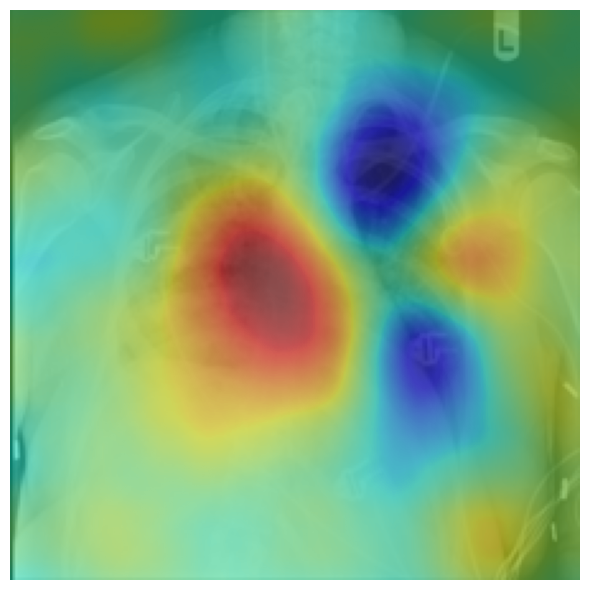

In [18]:
heatmaps_rise = []
for img_path in image_paths:
    img = Image.open(img_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)
    
    
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    
    idx = all_labels.index("Infiltration")
    
    print("Gerando mapa de saliência...")
    with torch.no_grad():
        sal = explainer(input_tensor)
        sal_map = sal[idx].cpu().numpy()
        heatmaps_rise.append(sal_map)


    plt.figure(figsize=(6, 6))
    
    # Imagem original
    img_display = np.array(img)
    
    raw_np = np.array(img.resize((224, 224))) / 255.0
    
    # Overlay
    plt.imshow(raw_np)
    plt.imshow(sal_map, cmap='jet', alpha=0.5)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()



In [19]:
broke_list = []
for image_path, heatmap in zip(image_paths, heatmaps_rise):
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]

    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, 'Infiltration', max_steps=1000)

    print(f"Broke at step: {broke}")
    if broke is not None:
        broke_list.append(broke)


print("Average broke: ", np.mean(broke_list))




Broke at step: 456
Broke at step: 1
Broke at step: 569
Broke at step: 2
Average broke:  257.0


In [20]:
robustness_score_list = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    robustness_score = robustness_test(model,'RISE', input_tensor, explainer)
    print(f"Robustness score: {robustness_score}")
    robustness_score_list.append(robustness_score)

print("Average robustness score: ", np.mean(robustness_score_list))

Processing masks: 100%|██████████| 30/30 [00:10<00:00,  2.77it/s]


Robustness score: 0.9670227766036987


Processing masks: 100%|██████████| 30/30 [00:10<00:00,  2.89it/s]


Robustness score: 0.970302939414978


Processing masks: 100%|██████████| 30/30 [00:10<00:00,  2.88it/s]


Robustness score: 0.9780347943305969


Processing masks: 100%|██████████| 30/30 [00:10<00:00,  2.85it/s]


Robustness score: 0.9836757779121399
Average robustness score:  0.9747591


In [21]:
gini_list = []
coherence_list = []
for heatmap in heatmaps_rise:
    sal_map = heatmap
    gini_index = calculate_gini_index(sal_map)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)
    coherence = calculate_spatial_coherence(sal_map)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print("Average Gini Index: ", np.mean(gini_list))
print("Average Spatial Coherence: ", np.mean(coherence_list))

Gini Index: 0.056470676344268174
Spatial Coherence: 0.9572544097900391
Gini Index: 0.08277807430345185
Spatial Coherence: 0.9082276225090027
Gini Index: 0.053059169224330356
Spatial Coherence: 0.9279552102088928
Gini Index: 0.04245267595563616
Spatial Coherence: 0.6095405220985413
Average Gini Index:  0.05869014895692164
Average Spatial Coherence:  0.8507444


In [22]:
consistency = intraclass_consistency(heatmaps_rise)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.319280584681354


In [23]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 16.1 MB/s eta 0:00:00:00:0100:01
  Attempting unins

In [24]:
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

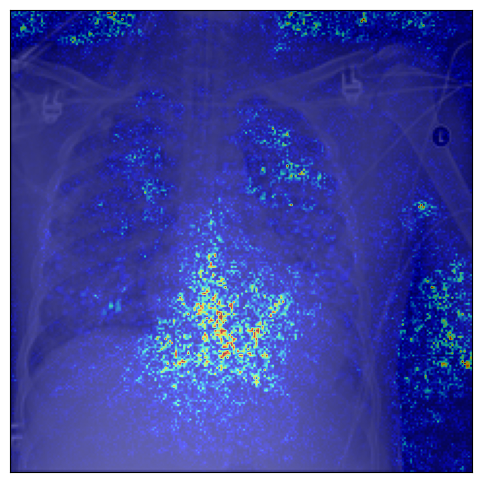

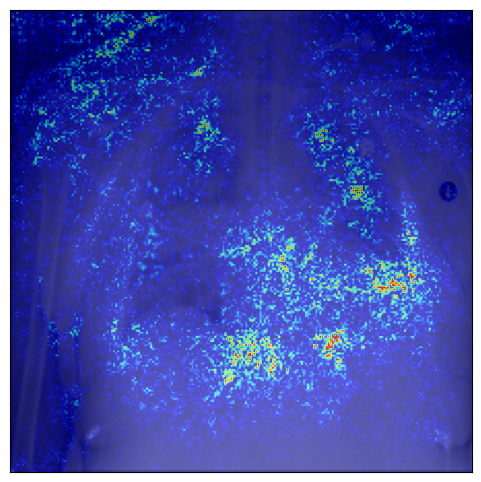

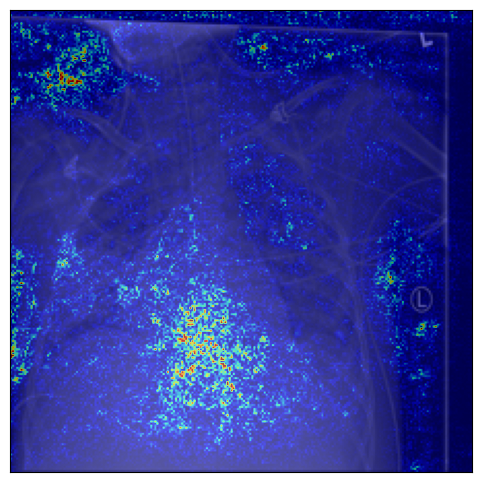

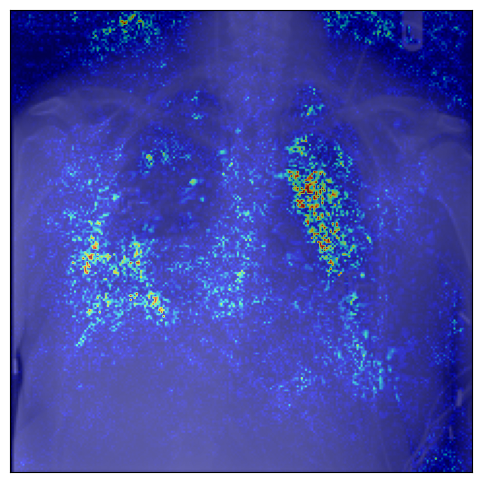

In [ ]:
ig = IntegratedGradients(model)
heatmaps_ig = []
i=1
for img_path in image_paths:
    img = Image.open(img_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(next(model.parameters()).device)
    input_tensor.requires_grad_()
    
    
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]
    idx = all_labels.index("Infiltration")
    
    
    baseline = torch.zeros_like(input_tensor).to(device)
    
    attributions_ig = ig.attribute(input_tensor,
                                   baselines=baseline,
                                   target=idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    
    
    attr_np = attributions_ig.squeeze().cpu().detach().numpy()
    attr_np = np.transpose(attr_np, (1, 2, 0))
    sal_map = np.mean(np.abs(attr_np), axis=2)
    heatmaps_ig.append(sal_map)
    img_np = np.array(img.resize((224, 224))) / 255.0
    
    fig, _ = viz.visualize_image_attr(
        attr_np,
        img_np,
        method="blended_heat_map",
        sign="absolute_value", 
        show_colorbar=False,
        use_pyplot=True,
        cmap="jet",            
        outlier_perc=2,        
        alpha_overlay=0.6      
    )

    plt.savefig(f'cub_ig_{i}')
    plt.close()
    i += 1

In [27]:
broke_list = []
for image_path, heatmap in zip(image_paths, heatmaps_ig):
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0]
    
    # labels com prob > 0.5
    predicted = [all_labels[i] for i, p in enumerate(probs) if p > 0.5]

    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, 'Infiltration', max_steps=3000)

    print(f"Broke at step: {broke}")
    if broke is not None:
        broke_list.append(broke)


print("Average broke: ", np.mean(broke_list))

Broke at step: 502
Broke at step: 1
Broke at step: 2796
Broke at step: 37
Average broke:  834.0


In [28]:
robustness_score_list = []
for image_path in image_paths:
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    robustness_score = robustness_test(model,'IG', input_tensor, ig.attribute)
    print(f"Robustness score: {robustness_score}")
    robustness_score_list.append(robustness_score)

print("Average robustness score: ", np.mean(robustness_score_list))


Robustness score: 0.006292098201811314
Robustness score: -0.00571034848690033
Robustness score: 0.02824796363711357
Robustness score: 0.013451230712234974
Average robustness score:  0.010570236


In [29]:
gini_list = []
coherence_list = []
for heatmap in heatmaps_ig:
    sal_map = heatmap
    gini_index = calculate_gini_index(sal_map)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)
    coherence = calculate_spatial_coherence(sal_map)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print("Average Gini Index: ", np.mean(gini_list))
print("Average Spatial Coherence: ", np.mean(coherence_list))

Gini Index: 0.5997328466298629
Spatial Coherence: 0.7817264199256897
Gini Index: 0.5284825149847536
Spatial Coherence: 0.40006089210510254
Gini Index: 0.5461829827756298
Spatial Coherence: 0.4401843547821045
Gini Index: 0.5518691004539023
Spatial Coherence: 0.46358489990234375
Average Gini Index:  0.556566861211037
Average Spatial Coherence:  0.5213891


In [30]:
consistency = intraclass_consistency(heatmaps_ig)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.1351236038394412
